# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1.
2.
3.
4.
5.


In [1]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

Cloning into 'cs4250'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 94 (delta 41), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.26 MiB | 29.28 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [3]:
def load_image_gray(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) +
    return image

In [4]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.

In [5]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y


array([[  5,  18,  14, ..., 198, 196, 194],
       [ 11,  12,  18, ..., 196, 194, 192],
       [ 12,   6,  12, ..., 193, 190, 188],
       ...,
       [ 95,  90,  34, ...,  70,  82,  83],
       [ 94,  83,  20, ...,  52,  62,  59],
       [ 94,  79,  11, ...,  56,  68,  22]], dtype=uint8)
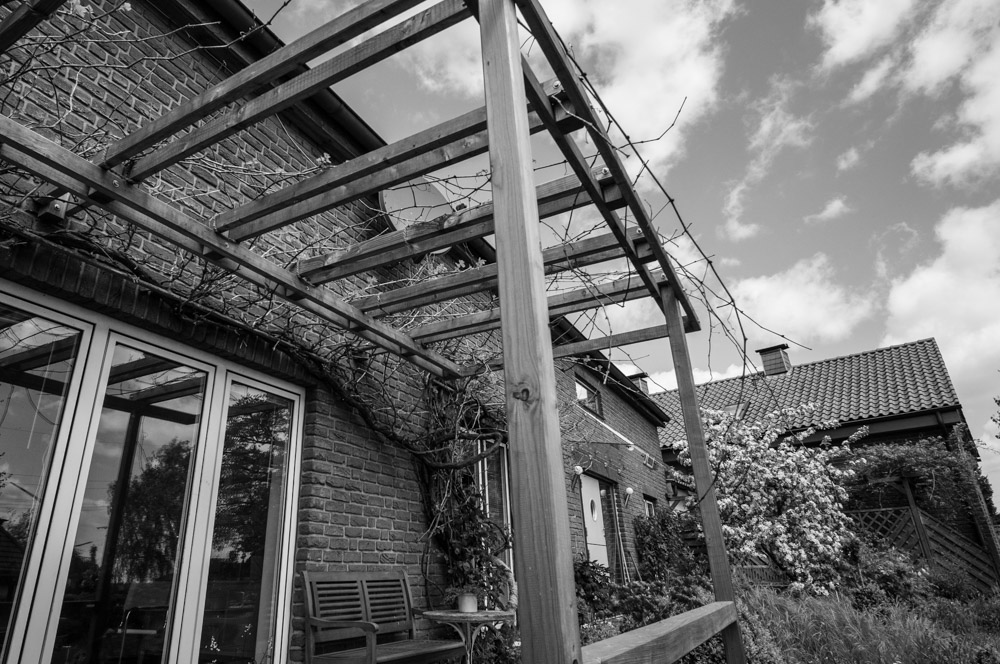

In [12]:
load_image_gray("/content/cs4250/data/exercise_3/ueb312.jpg")


## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

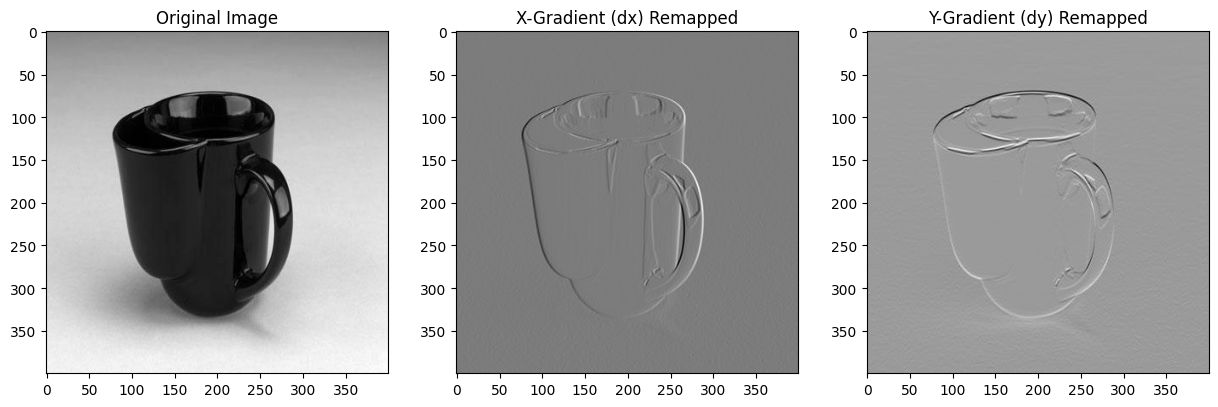

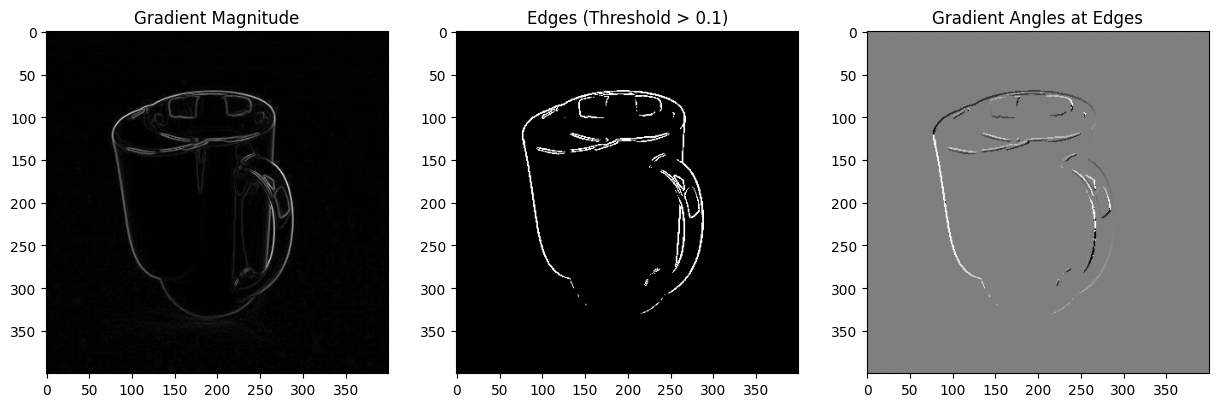

In [32]:
# Load the image, converting it to grayscale and normalizing it to a 0-1 range
img = load_image_gray_normalized("data/exercise_3/ueb32.jpg")

# 1. Compute the gradient images
dx, dy = gradient(img)

# --- New Method for making images comparable ---
# Find the shared min and max across both gradient arrays
shared_min = min(dx.min(), dy.min())
shared_max = max(dx.max(), dy.max())

# Remap both arrays to the [0, 1] range using the shared values
dx_display = (dx - shared_min) / (shared_max - shared_min)
dy_display = (dy - shared_min) / (shared_max - shared_min)
# --- End of new method ---

# Plot the original image and the two remapped gradients
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original Image")
ax[1].imshow(dx_display, cmap='gray')
ax[1].set_title("X-Gradient (dx) Remapped")
ax[2].imshow(dy_display, cmap='gray')
ax[2].set_title("Y-Gradient (dy) Remapped")
plt.show()


# 2. Compute gradient magnitude and apply a threshold
grad_magnitude = np.sqrt(dx**2 + dy**2)

# Apply a threshold to retain only the strong edges
threshold = 0.1
edges_mask = grad_magnitude > threshold


# 3. Compute and show the gradient angle image for the detected edges
# The result from np.arctan2 is in radians, so we convert it to degrees
grad_angle = np.arctan2(dy, dx) * 180 / np.pi

# We only want to see the angles for the pixels that are actually part of an edge
angle_at_edges = np.copy(grad_angle)
angle_at_edges[~edges_mask] = 0 # Set non-edge pixels to 0


# Plot the magnitude, the thresholded edges, and the angles at the edges
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(grad_magnitude, cmap='gray')
ax[0].set_title("Gradient Magnitude")
ax[1].imshow(edges_mask, cmap='gray')
ax[1].set_title(f"Edges (Threshold > {threshold})")
ax[2].imshow(angle_at_edges, cmap='gray')
ax[2].set_title("Gradient Angles at Edges")
plt.show()

## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.**Furthermore, comment how the angle image and the magnitude image are used in the Canny algorithm.**

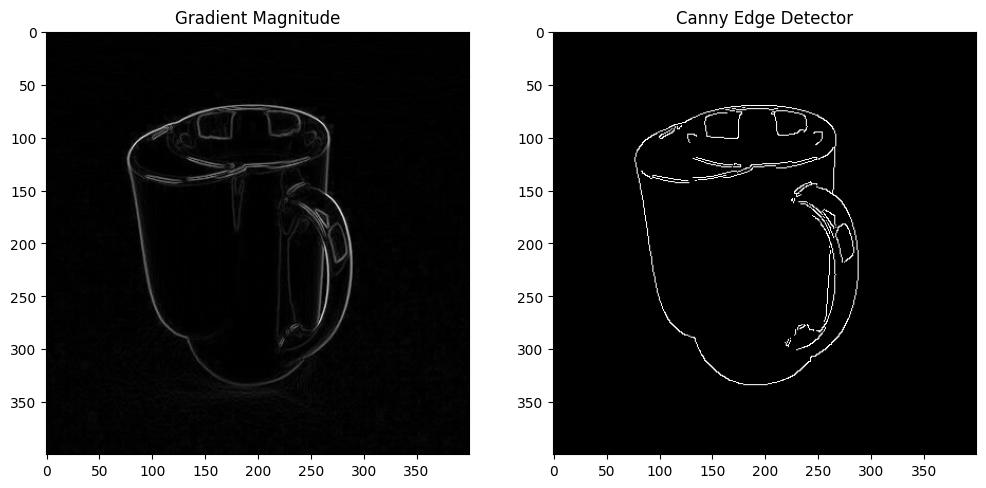

In [34]:
# load image
# compute magnitude of gradient image
# apply canny
# compare results

# --- Main execution ---

# 1. Load the image in two formats:
#    - Normalized float for manual gradient calculation
#    - 8-bit integer for the OpenCV Canny function
img_normalized = load_image_gray_normalized("data/exercise_3/ueb32.jpg")
img_uint8 = cv2.imread("data/exercise_3/ueb32.jpg", cv2.IMREAD_GRAYSCALE)

# 2. Compute the gradient magnitude image
dx, dy = gradient(img_normalized)
grad_magnitude = np.sqrt(dx**2 + dy**2)

# 3. Apply the OpenCV Canny algorithm
#    The two threshold values are for hysteresis thresholding.
min_threshold = 100
max_threshold = 200
canny_edges = cv2.Canny(img_uint8, min_threshold, max_threshold)

# 4. Compare the results side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(grad_magnitude, cmap='gray')
ax[0].set_title("Gradient Magnitude")

ax[1].imshow(canny_edges, cmap='gray')
ax[1].set_title("Canny Edge Detector")

plt.show()

## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [35]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [36]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [37]:
def key_points_structure(image, alpha, sigma=.1):
    """
    Detects keypoints using the structure tensor invariants K and K - alpha*H^2.
    """
    # 0. Filter with a small Gaussian kernel for differentiation scale
    image_blur = cv2.GaussianBlur(image, (5, 5), sigma)

    # 1. Compute partial derivatives (gradients)
    dx, dy = gradient(image_blur)

    # 2. Compute the gradient product images
    dx2 = dx**2
    dy2 = dy**2
    dxdy = dx * dy

    # 3. Filter with a Gaussian kernel for integration scale (forms the structure tensor)
    # This is the crucial second filtering step.
    J_11 = cv2.GaussianBlur(dx2, (5, 5), 1)
    J_22 = cv2.GaussianBlur(dy2, (5, 5), 1)
    J_12 = cv2.GaussianBlur(dxdy, (5, 5), 1)

    # 4. Compute invariants K and H for the structure tensor J
    # K = det(J) = J11*J22 - J12^2
    # H = trace(J) = J11 + J22
    K = (J_11 * J_22) - (J_12**2)
    H = J_11 + J_22

    # 5. Compute the Harris corner response: K - alpha * H^2
    K_minus_H = K - alpha * H**2

    return K, K_minus_H

In [3]:
# Define parameters
alpha = 0.0003
sigma = 0.3
k = 21 # For find_local_max

# Load images
img_synthetic = np.load("data/exercise_3/ueb331.npy")
img_real = load_image_gray_normalized("data/exercise_3/ueb332.jpg")
images = {'Synthetic Image': img_synthetic, 'Real Image': img_real}

# Create subplots
fig, ax = plt.subplots(2, 2, figsize=(12, 12))

# Process and plot for both images
for i, (title, img) in enumerate(images.items()):
    # Extract keypoints
    keypoints_K, keypoints_K_minus_H = key_points_structure(img, alpha=alpha, sigma=sigma)

    # Find local maxima for K
    local_max_K = find_local_max(keypoints_K, thres=1e-6, k=k)
    ax[i][0].imshow(img, cmap='gray')
    ax[i][0].set_title(f"{title}: Detector K")
    plot_marks(local_max_K, ax[i][0])

    # Find local maxima for K - alpha * H^2
    local_max_K_minus_H = find_local_max(keypoints_K_minus_H, thres=1e-6, k=k)
    ax[i][1].imshow(img, cmap='gray')
    ax[i][1].set_title(f"{title}: Detector K - alpha * H^2")
    plot_marks(local_max_K_minus_H, ax[i][1])

plt.tight_layout()
plt.show()


NameError: name 'np' is not defined